In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("../data/processed_data.csv")
df

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male
0,80.0,0,1,25.19,6.6,140,0,0
1,54.0,0,0,27.32,6.6,80,0,0
2,28.0,0,0,27.32,5.7,158,0,1
3,36.0,0,0,23.45,5.0,155,0,0
4,76.0,1,1,20.14,4.8,155,0,1
...,...,...,...,...,...,...,...,...
99977,80.0,0,0,27.32,6.2,90,0,0
99978,2.0,0,0,17.37,6.5,100,0,0
99979,66.0,0,0,27.83,5.7,155,0,1
99980,24.0,0,0,35.42,4.0,100,0,0


In [3]:
X = df.drop(columns = ["diabetes"])
y = df["diabetes"]

In [4]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
clf = GaussianNB()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
print(cross_val_score(clf, X_train, y_train, cv=5))
print(cross_val_score(clf, X_train, y_train, cv=5, scoring='f1'))

[0.90510721 0.9018566  0.90041883 0.90423204 0.90523223]
[0.53747715 0.51692308 0.52405139 0.53743961 0.53948967]


In [6]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     18297
           1       0.46      0.65      0.54      1700

    accuracy                           0.91     19997
   macro avg       0.71      0.79      0.74     19997
weighted avg       0.92      0.91      0.91     19997



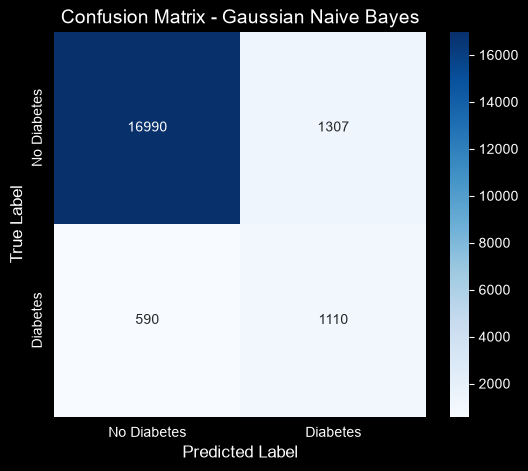

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Gaussian Naive Bayes', fontsize=14)
plt.show()

Because of class imbalance, the model struggles to predict diabetes accurately.

In [8]:
y_probs = clf.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs >= 0.4).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95     18297
           1       0.45      0.67      0.54      1700

    accuracy                           0.90     19997
   macro avg       0.71      0.80      0.74     19997
weighted avg       0.92      0.90      0.91     19997



In [9]:
clf_priors = GaussianNB(priors=[0.5, 0.5])
clf_priors.fit(X_train, y_train)

y_pred_priors = clf_priors.predict(X_test)
print(classification_report(y_test, y_pred_priors))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94     18297
           1       0.42      0.77      0.54      1700

    accuracy                           0.89     19997
   macro avg       0.70      0.84      0.74     19997
weighted avg       0.93      0.89      0.90     19997



In [10]:
strong_features = ['blood_glucose_level', 'HbA1c_level', 'age', 'bmi', 'hypertension']

clf_select = GaussianNB()
clf_select.fit(X_train[strong_features], y_train)

y_pred_select = clf_select.predict(X_test[strong_features])
print(classification_report(y_test, y_pred_select))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96     18297
           1       0.52      0.65      0.58      1700

    accuracy                           0.92     19997
   macro avg       0.74      0.80      0.77     19997
weighted avg       0.93      0.92      0.92     19997



Due to the severe class imbalance in the dataset (~91.5% Non-Diabetes vs ~8.5% Diabetes), the model achieves high overall accuracy but struggles with precision and F1-score for the positive class (Diabetes). so we have to use Random Forest or something else.